# Task 5 — Geographic and Geospatial Analysis

The network notebook treated the grid as pure topology. This one puts it back on
the map: where the assets actually are, how far apart, which parts of the country
are thin on coverage, and an interactive Folium map that the report and dashboard
both link to.

In [1]:
import sys

sys.path.append("../src")

import folium
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from geopy.distance import geodesic

import griddata

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data, _ = griddata.clean(griddata.load_raw())
utilities, substations, lines = data["utilities"], data["substations"], data["lines"]
master = griddata.build_master(data)

OUT = "../outputs"

## 1. Verify the line lengths against the coordinates

`lines.csv` ships a `Length (km)` column. Trust but verify: recompute the geodesic
(great-circle) distance between each line's endpoints and compare. The generator
multiplied straight-line distance by a routing factor of 1.05–1.3 (real lines
follow roads and terrain, not crow-flight), so the stated length should sit a
little *above* geodesic, never below.

count    55.000
mean      1.167
std       0.068
min       1.068
25%       1.104
50%       1.153
75%       1.216
max       1.298
Name: Routing factor, dtype: float64

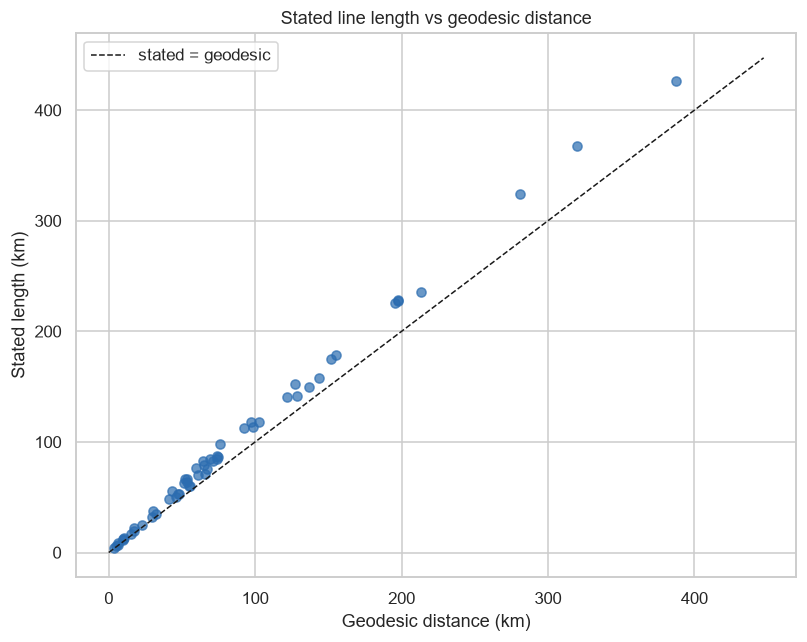

In [2]:
check = master.copy()
check["Geodesic (km)"] = check.apply(
    lambda r: geodesic((r["Latitude_src"], r["Longitude_src"]),
                       (r["Latitude_dst"], r["Longitude_dst"])).km,
    axis=1,
).round(1)
check["Routing factor"] = (check["Length (km)"] / check["Geodesic (km)"]).round(3)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(check["Geodesic (km)"], check["Length (km)"], alpha=0.7, color="#2b6cb0")
lim = max(check["Length (km)"].max(), check["Geodesic (km)"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="stated = geodesic")
ax.set_xlabel("Geodesic distance (km)")
ax.set_ylabel("Stated length (km)")
ax.set_title("Stated line length vs geodesic distance")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT}/g1_length_verification.png", bbox_inches="tight")

check["Routing factor"].describe().round(3)

Every point sits on or above the diagonal and the routing factor stays inside
1.05–1.3 — the lengths are internally consistent with the coordinates. In a real
register, points *below* the diagonal would be the first rows to audit: a stated
length shorter than the straight-line distance is physically impossible.

## 2. Line length categories

In [3]:
check["Length class"] = pd.cut(
    check["Length (km)"],
    bins=[0, 50, 150, 10_000],
    labels=["Short (<50 km)", "Medium (50–150 km)", "Long (>150 km)"],
)
class_stats = (
    check.groupby("Length class", observed=True)
    .agg(Lines=("Line ID", "count"),
         Median_km=("Length (km)", "median"),
         Interregional=("Inter-regional", "sum"))
)
class_stats

,Lines,Median_km,Interregional
Length class,,,
Short (<50 km),15,17.1,1
Medium (50–150 km),29,79.5,5
Long (>150 km),11,227.0,10


The split maps almost perfectly onto function: short lines are intra-regional
distribution, medium ones join neighbouring regions, and the long tail is the
330 kV backbone plus the border interconnectors. Length class is effectively a
proxy for grid role in this dataset.

## 3. Substation density: which regions look underserved?

The dataset has no population column, so "underserved" here is asset count and
capacity per region only — with the caveat that a region's total capacity says
nothing about where within the region it sits.

,Substations,Capacity,Oldest
Region,,,
Ashanti,5,1099.6,1989
Eastern,4,828.5,1975
Upper East,2,520.7,1971
Greater Accra,6,520.2,1970
Volta,4,470.3,1980
Western,4,323.0,1967
Central,4,316.2,1970
Bono,3,252.6,1999
Northern,3,155.6,1969


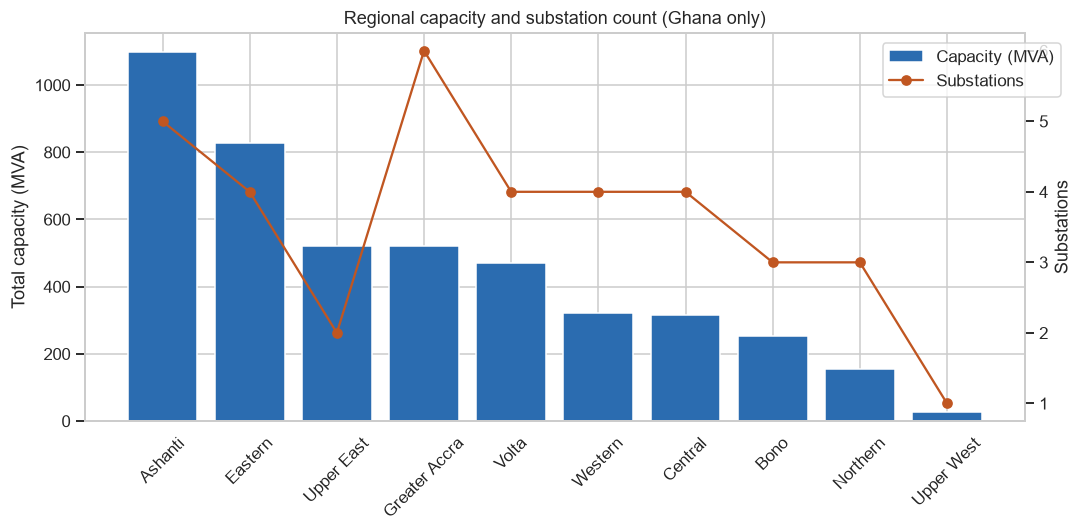

In [4]:
regional = (
    substations[substations["Country"] == "Ghana"]
    .groupby("Region", observed=True)
    .agg(Substations=("Substation ID", "count"),
         Capacity=("Capacity (MVA)", "sum"),
         Oldest=("Commissioning Year", "min"))
    .sort_values("Capacity", ascending=False)
    .round(1)
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(regional.index, regional["Capacity"], color="#2b6cb0", label="Capacity (MVA)")
ax1.set_ylabel("Total capacity (MVA)")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(regional.index, regional["Substations"], "o-", color="#c05621", label="Substations")
ax2.set_ylabel("Substations")
ax2.grid(False)
ax1.set_title("Regional capacity and substation count (Ghana only)")
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.92))
fig.tight_layout()
fig.savefig(f"{OUT}/g2_regional_density.png", bbox_inches="tight")
regional

The three northern regions (Northern, Upper East, Upper West) sit at the bottom on
both measures — and Savelugu, one of Northern's three substations, has no lines at
all, so the north's *effective* connectivity is thinner than even these counts
suggest. That matches the real-world pattern of southern-concentrated generation
and load in Ghana, though the specific numbers remain synthetic.

## 4. The interactive map

Folium map with three toggleable layers:
- **Substations**, coloured by voltage tier, popup with the asset details
- **Lines**, styled by status (maintenance lines dashed orange)
- **Utility view**: one colour per operating utility

Saved as `../outputs/grid_map.html` — open it in a browser.

In [5]:
VOLTAGE_COLOURS = {11: "#6b7280", 33: "#2563eb", 69: "#059669", 161: "#d97706", 330: "#dc2626"}
UTILITY_COLOURS = {
    "ECG": "#2563eb", "NED": "#059669", "GRD": "#dc2626",
    "SNB": "#7c3aed", "CIE": "#d97706", "CEB": "#0891b2",
}

m = folium.Map(location=[7.9, -1.0], zoom_start=7, tiles="cartodbpositron")

sub_layer = folium.FeatureGroup(name="Substations (by voltage)")
for _, s in substations.iterrows():
    popup = folium.Popup(
        f"<b>{s['Name']}</b><br>"
        f"Region: {s['Region']}<br>"
        f"Voltage: {s['Voltage (kV)']} kV — {s['Type']}<br>"
        f"Capacity: {s['Capacity (MVA)']} MVA<br>"
        f"Commissioned: {s['Commissioning Year']}<br>"
        f"Status: {s['Status']}",
        max_width=260,
    )
    folium.CircleMarker(
        location=[s["Latitude"], s["Longitude"]],
        radius=4 + s["Capacity (MVA)"] / 90,
        color=VOLTAGE_COLOURS[s["Voltage (kV)"]],
        fill=True, fill_opacity=0.85,
        popup=popup,
        tooltip=s["Short Name"],
    ).add_to(sub_layer)
sub_layer.add_to(m)

line_layer = folium.FeatureGroup(name="Lines (by status)")
for _, l in master.iterrows():
    maintenance = l["Status"] == "Under Maintenance"
    folium.PolyLine(
        locations=[[l["Latitude_src"], l["Longitude_src"]], [l["Latitude_dst"], l["Longitude_dst"]]],
        weight=3 if l["Voltage (kV)"] >= 161 else 1.5,
        color="#ed8936" if maintenance else "#4a5568",
        dash_array="6" if maintenance else None,
        opacity=0.8,
        tooltip=f"{l['Source Substation']} - {l['Destination Substation']} "
                f"({l['Voltage (kV)']} kV, {l['Length (km)']} km, {l['Status']})",
    ).add_to(line_layer)
line_layer.add_to(m)

utility_layer = folium.FeatureGroup(name="Lines (by utility)", show=False)
for _, l in master.iterrows():
    folium.PolyLine(
        locations=[[l["Latitude_src"], l["Longitude_src"]], [l["Latitude_dst"], l["Longitude_dst"]]],
        weight=2.5,
        color=UTILITY_COLOURS.get(l["Code"], "#6b7280"),
        opacity=0.8,
        tooltip=f"{l['Code']}: {l['Source Substation']} - {l['Destination Substation']}",
    ).add_to(utility_layer)
utility_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save(f"{OUT}/grid_map.html")
print("saved outputs/grid_map.html")
m

saved outputs/grid_map.html


## 5. Geographic clusters of high-capacity substations

In [6]:
big = substations.nlargest(12, "Capacity (MVA)")
coastal = big[big["Latitude"] < 6.5]
border = big[big["Country"] != "Ghana"]
print(f"top 12 by capacity: {len(coastal)} on the southern coast belt, "
      f"{len(border)} at borders/abroad, {12 - len(coastal.index.union(border.index).unique())} inland")
big[["Short Name", "Region", "Country", "Voltage (kV)", "Capacity (MVA)"]]

top 12 by capacity: 5 on the southern coast belt, 6 at borders/abroad, 5 inland


,Short Name,Region,Country,Voltage (kV),Capacity (MVA)
40,Cotonou Transmission Hub,Benin,Benin,161,487.6
42,Bobo-Dioulasso Hub,Burkina Faso,Burkina,161,445.9
38,Aflao Border Station,Togo border,Togo,330,423.2
21,Nkawkaw,Eastern,Ghana,69,389.2
23,Ho,Volta,Ghana,330,382.1
7,Ejisu,Ashanti,Ghana,330,355.9
22,Suhum,Eastern,Ghana,69,339.0
33,Bolgatanga,Upper East,Ghana,161,325.9
10,Konongo,Ashanti,Ghana,69,285.2
37,Elubo Border Station,Cote d'Ivoire border,Cote,330,285.1


High capacity concentrates in two places: the WAPP border hubs (built big because
they carry international transfers) and the southern industrial belt. The far
north's biggest asset is the Bolgatanga interconnection corridor — its capacity
exists to move power *through* the region toward Burkina Faso, not to serve it.

## Takeaways

1. Stated line lengths verify against coordinates (routing factor 1.05–1.3, none
   impossible).
2. Length class ≈ grid role: short = local distribution, long = backbone/border.
3. The northern third of the country is thinnest on assets, capacity and — counting
   Savelugu's missing lines — connectivity.
4. Capacity clusters at borders and the coast; the interactive map makes the
   corridor structure obvious at a glance.